# 🛒 Dự đoán Khách Hàng Rời Bỏ (Customer Churn Prediction)
### Dataset: Online Retail

---

## 📌 Mục tiêu
Dự đoán khách hàng nào **có nguy cơ rời bỏ** (không mua hàng trong 90 ngày tới) dựa trên lịch sử mua hàng.

## 📋 Các bước thực hiện
1. Đọc và làm sạch dữ liệu
2. Phân tích chu kỳ mua để xác định ngưỡng 90 ngày
3. Tạo đặc trưng (features) — bao gồm ngưỡng churn cá nhân hóa μ + 2σ
4. Kiểm định thống kê (T-Test & Chi-Square) để chọn biến
5. Huấn luyện Logistic Regression và XGBoost (đã được tinh chỉnh)
6. Đánh giá, so sánh và xếp hạng khách hàng theo nguy cơ

---

## 📦 Bước 0: Cài đặt và import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import xgboost as xgb

print('✅ Import thư viện thành công!')


✅ Import thư viện thành công!


---
## 🗂️ Bước 1: Đọc và làm sạch dữ liệu

In [2]:
# ============================================================
# ĐỌC DỮ LIỆU
# Trên Google Colab: uncomment 2 dòng dưới để upload file
# ============================================================

# from google.colab import files
# files.upload()   # chọn file Online_Retail.xlsx

df = pd.read_excel(r"C:\Users\admin\Downloads\Online_Retail (2).xlsx")

print('Shape dữ liệu gốc:', df.shape)
df.head()


Shape dữ liệu gốc: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# ============================================================
# LÀM SẠCH DỮ LIỆU
# ============================================================

# Chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Chuyển cột ngày về đúng kiểu datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Xóa các dòng thiếu CustomerID (không biết ai mua → không dự đoán được)
df = df.dropna(subset=['customerid'])
df['customerid'] = df['customerid'].astype(int)

# Xóa đơn hủy (bắt đầu bằng chữ C)
df = df[~df['invoiceno'].astype(str).str.startswith('C')]

# Chỉ giữ giao dịch hợp lệ — loại luôn dữ liệu nhập sai (quantity/price âm hoặc = 0)
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]

# Tạo cột doanh thu mỗi dòng
df['revenue'] = df['quantity'] * df['unitprice']

print('Shape sau khi làm sạch:', df.shape)
print('\nKiểu dữ liệu các cột:')
print(df.dtypes)


Shape sau khi làm sạch: (397884, 9)

Kiểu dữ liệu các cột:
invoiceno              object
stockcode              object
description            object
quantity                int64
invoicedate    datetime64[us]
unitprice             float64
customerid              int64
country                   str
revenue               float64
dtype: object


---
## 📐 Bước 2: Phân tích chu kỳ mua — lý do chọn ngưỡng 90 ngày

Trước khi gán nhãn churn, cần kiểm tra phân phối **số ngày giữa các lần mua** để đảm bảo ngưỡng 90 ngày có cơ sở thống kê.

Trung vị số ngày giữa 2 lần mua: 28.0 ngày
80% khoảng cách mua nằm dưới   : 70.0 ngày
90% khoảng cách mua nằm dưới   : 111.0 ngày

→ Chọn 90 ngày: bao phủ ~90% các chu kỳ mua bình thường


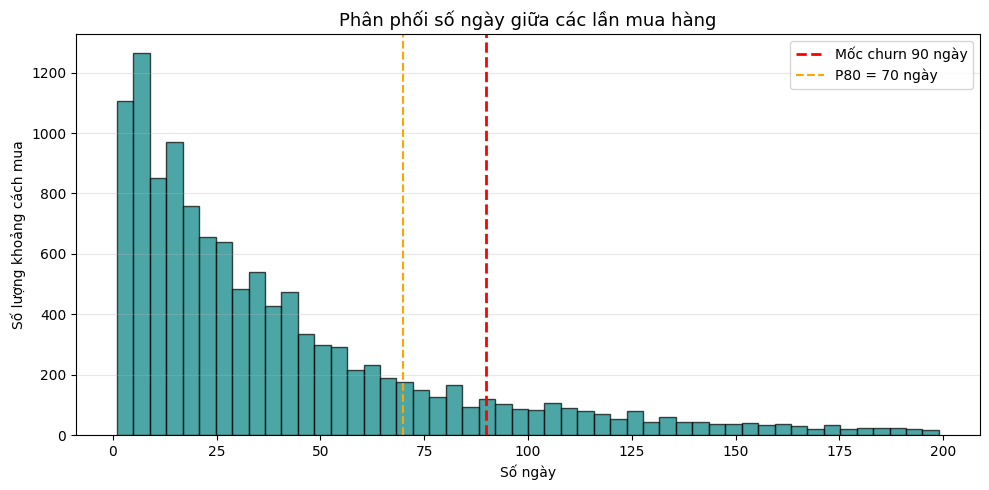

In [4]:
# ============================================================
# PHÂN TÍCH CHU KỲ MUA ĐỂ XÁC ĐỊNH NGƯỠNG 90 NGÀY
# ============================================================

# Lấy danh sách đơn hàng, mỗi đơn 1 dòng, sắp xếp theo thời gian
orders_ipt = (
    df[['customerid', 'invoiceno', 'invoicedate']]
    .drop_duplicates()
    .sort_values(['customerid', 'invoicedate'])
    .copy()
)

# Tính khoảng cách (ngày) giữa 2 lần mua liên tiếp của cùng 1 khách
orders_ipt['prev_date']    = orders_ipt.groupby('customerid')['invoicedate'].shift(1)
orders_ipt['days_between'] = (orders_ipt['invoicedate'] - orders_ipt['prev_date']).dt.days

# Loại bỏ NaN (lần mua đầu tiên) và khoảng cách = 0 (cùng ngày)
ipt_values = orders_ipt['days_between'].dropna()
ipt_values = ipt_values[ipt_values > 0]

# Tính các phân vị quan trọng
p80_ipt = ipt_values.quantile(0.80)
p90_ipt = ipt_values.quantile(0.90)

print(f'Trung vị số ngày giữa 2 lần mua: {ipt_values.median():.1f} ngày')
print(f'80% khoảng cách mua nằm dưới   : {p80_ipt:.1f} ngày')
print(f'90% khoảng cách mua nằm dưới   : {p90_ipt:.1f} ngày')
print(f'\n→ Chọn 90 ngày: bao phủ ~90% các chu kỳ mua bình thường')

# Vẽ biểu đồ phân phối
plt.figure(figsize=(10, 5))
plt.hist(ipt_values[ipt_values < 200], bins=50,
         color='teal', edgecolor='black', alpha=0.7)
plt.axvline(90, color='red', linestyle='--', linewidth=2, label='Mốc churn 90 ngày')
plt.axvline(p80_ipt, color='orange', linestyle='--', linewidth=1.5, label=f'P80 = {p80_ipt:.0f} ngày')
plt.title('Phân phối số ngày giữa các lần mua hàng', fontsize=13)
plt.xlabel('Số ngày')
plt.ylabel('Số lượng khoảng cách mua')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 🔧 Bước 3: Tạo đặc trưng (Feature Engineering)

### 💡 Logic tạo nhãn Churn
```
Timeline:
|--- Observation Window (tính features) ---|--- Prediction Window (90 ngày) ---|
01/12/2010                            31/08/2011                          30/11/2011
```
Khách hàng được gán nhãn **Churn = 1** nếu **không mua hàng** trong cửa sổ 90 ngày dự đoán.

### 🎯 Ngưỡng churn cá nhân hóa μ + 2σ
Thay vì dùng 90 ngày cứng nhắc cho tất cả, ta còn tính ngưỡng riêng cho từng khách dựa trên thói quen mua của họ:
- **μ** = số ngày trung bình giữa 2 lần mua
- **σ** = độ lệch chuẩn (mức độ biến động)
- **Ngưỡng = μ + 2σ** → nếu recency vượt ngưỡng này → khách đã "bất thường" so với chính họ

In [5]:
# ============================================================
# CHIA CỬA SỔ THỜI GIAN
# ============================================================

cutoff_date = pd.Timestamp('2011-09-01')  # Ngày phân chia
end_date    = pd.Timestamp('2011-12-01')  # Kết thúc cửa sổ dự đoán

df_obs  = df[df['invoicedate'] < cutoff_date].copy()                              # Cửa sổ quan sát
df_pred = df[(df['invoicedate'] >= cutoff_date) & (df['invoicedate'] < end_date)].copy()  # Cửa sổ dự đoán

print(f'Cửa sổ quan sát : {df_obs["invoicedate"].min().date()} → {df_obs["invoicedate"].max().date()}')
print(f'Số giao dịch    : {len(df_obs):,}')
print(f'\nCửa sổ dự đoán : {cutoff_date.date()} → {end_date.date()}')
print(f'Số giao dịch    : {len(df_pred):,}')


Cửa sổ quan sát : 2010-12-01 → 2011-08-31
Số giao dịch    : 226,467

Cửa sổ dự đoán : 2011-09-01 → 2011-12-01
Số giao dịch    : 154,113


In [6]:
# ============================================================
# TẠO NHÃN CHURN (y)
# Churn = 1 nếu khách KHÔNG mua trong cửa sổ dự đoán
# ============================================================

customers_obs  = set(df_obs['customerid'].unique())
customers_pred = set(df_pred['customerid'].unique())

labels = pd.DataFrame({'customerid': list(customers_obs)})
labels['churn'] = labels['customerid'].apply(
    lambda cid: 0 if cid in customers_pred else 1
    # 0 = ở lại (vẫn mua trong 90 ngày), 1 = rời bỏ (không mua nữa)
)

print('Phân phối nhãn Churn:')
print(labels['churn'].value_counts())
print(f'\nTỷ lệ Churn: {labels["churn"].mean():.1%}')


Phân phối nhãn Churn:
churn
0    1871
1    1446
Name: count, dtype: int64

Tỷ lệ Churn: 43.6%


In [7]:
# ============================================================
# TẠO FEATURES — PHẦN 1: RFM CƠ BẢN
# ============================================================

snapshot_date = cutoff_date

rfm = df_obs.groupby('customerid').agg(
    recency         = ('invoicedate', lambda x: (snapshot_date - x.max()).days),
    # Recency: số ngày kể từ lần mua cuối → càng cao càng dễ churn

    frequency       = ('invoiceno', 'nunique'),
    # Frequency: số đơn hàng khác nhau → càng thấp càng dễ churn

    monetary        = ('revenue', 'sum'),
    # Monetary: tổng doanh thu → khách giá trị thấp dễ churn hơn

    num_products    = ('stockcode', 'nunique'),
    # Số loại sản phẩm khác nhau → ít đa dạng = gắn kết yếu = dễ churn

    avg_order_value = ('revenue', lambda x: x.sum() / df_obs.loc[x.index, 'invoiceno'].nunique())
    # Giá trị đơn hàng trung bình
).reset_index()

print('RFM cơ bản đã tạo xong. Shape:', rfm.shape)
rfm.head()


RFM cơ bản đã tạo xong. Shape: (3317, 6)


,customerid,recency,frequency,monetary,num_products,avg_order_value
0,12346,225,1,77183.60,1,77183.600000
1,12347,29,5,2790.86,82,558.172000
2,12348,148,3,1487.24,22,495.746667
3,12350,210,1,334.40,17,334.400000
4,12352,162,5,1561.81,26,312.362000


In [9]:
# ============================================================
# TẠO FEATURES — PHẦN 2: CHU KỲ MUA HÀNG (μ và σ)
# ============================================================

def avg_purchase_interval(dates):
    """Tính khoảng cách TRUNG BÌNH (μ) giữa các lần mua"""
    unique_dates = sorted(dates.unique())
    if len(unique_dates) < 2:
        return np.nan  # Chỉ mua 1 lần → không tính được
    gaps = [(unique_dates[i+1] - unique_dates[i]).days for i in range(len(unique_dates)-1)]
    return np.mean(gaps)

def std_purchase_interval(dates):
    """Tính ĐỘ LỆCH CHUẨN (σ) giữa các lần mua"""
    unique_dates = sorted(dates.unique())
    if len(unique_dates) < 3:
        return np.nan  # Cần ít nhất 3 lần mua để tính σ có ý nghĩa
    gaps = [(unique_dates[i+1] - unique_dates[i]).days for i in range(len(unique_dates)-1)]
    return np.std(gaps)

# Tính μ
mean_iv = df_obs.groupby('customerid')['invoicedate'].apply(avg_purchase_interval).reset_index()
mean_iv.columns = ['customerid', 'avg_purchase_interval']

# Tính σ
std_iv = df_obs.groupby('customerid')['invoicedate'].apply(std_purchase_interval).reset_index()
std_iv.columns = ['customerid', 'std_interval']

# Ghép vào features
features = rfm.merge(mean_iv, on='customerid', how='left')
features = features.merge(std_iv,  on='customerid', how='left')

# Khách chỉ mua 1 lần: μ = recency, σ = 0
features['avg_purchase_interval'] = features['avg_purchase_interval'].fillna(features['recency'])
features['std_interval']          = features['std_interval'].fillna(0)

display(features.head())


,customerid,recency,frequency,monetary,num_products,avg_order_value,avg_purchase_interval,std_interval
0,12346,225,1,77183.60,1,77183.600000,225.00,0.000000
1,12347,29,5,2790.86,82,558.172000,58.75,8.257572
2,12348,148,3,1487.24,22,495.746667,54.50,15.500000
3,12350,210,1,334.40,17,334.400000,210.00,0.000000
4,12352,162,5,1561.81,26,312.362000,8.50,6.344289


In [10]:
# ============================================================
# TẠO FEATURES — PHẦN 3: 3 BIẾN MỚI CẢI THIỆN XGBOOST
# ============================================================

# --- Biến mới 1: Tỷ lệ chi tiêu gần đây so với trung bình ---
# Đo xu hướng: khách đang chi tiêu nhiều hơn hay ít hơn thói quen?
# spend_ratio < 1 → đang chi ít hơn bình thường → nguy cơ churn cao
recent_60d = df_obs[df_obs['invoicedate'] >= (cutoff_date - pd.Timedelta(days=60))]
spend_60d  = recent_60d.groupby('customerid')['revenue'].sum().reset_index()
spend_60d.columns = ['customerid', 'spend_last_60d']

features = features.merge(spend_60d, on='customerid', how='left')
features['spend_last_60d'] = features['spend_last_60d'].fillna(0)

# Quy về monthly rồi so với mức trung bình mỗi tháng (9 tháng quan sát)
features['spend_ratio'] = (
    features['spend_last_60d'] / 2          # → monthly gần đây
) / (features['monetary'] / 9 + 1)          # +1 để tránh chia 0

# --- Biến mới 2: Hệ số biến thiên chu kỳ mua (CV = σ/μ) ---
# Đo độ đều đặn: CV thấp = mua đều đặn = ít churn, CV cao = bất thường = dễ churn
features['cv_interval'] = (
    features['std_interval'] / (features['avg_purchase_interval'] + 1)
).fillna(1)   # Khách mua 1-2 lần: gán CV = 1 (mức trung bình)

# --- Biến mới 3: Đã vượt ngưỡng cá nhân hóa μ + 2σ chưa? ---
# Đây là tín hiệu mạnh nhất: kết hợp recency + thói quen cá nhân
features['personal_threshold'] = (
    features['avg_purchase_interval'] + 2 * features['std_interval']
).clip(upper=180)   # Đặt trần 180 ngày — tránh ngưỡng vô lý với seasonal buyer

features['exceeded_threshold'] = (
    features['recency'] > features['personal_threshold']
).astype(int)
# exceeded_threshold = 1 → khách đã vắng lâu hơn thói quen của chính họ → rất có thể đã churn

print('3 biến mới đã tạo xong.')
print('Tổng số features hiện tại:', features.shape[1] - 1, '(không tính customerid)')
features.head()


3 biến mới đã tạo xong.
Tổng số features hiện tại: 12 (không tính customerid)


,customerid,recency,frequency,monetary,num_products,avg_order_value,avg_purchase_interval,std_interval,spend_last_60d,spend_ratio,cv_interval,personal_threshold,exceeded_threshold
0,12346,225,1,77183.60,1,77183.600000,225.00,0.000000,0.00,0.000000,0.000000,180.000000,1
1,12347,29,5,2790.86,82,558.172000,58.75,8.257572,584.91,0.940081,0.138202,75.265145,0
2,12348,148,3,1487.24,22,495.746667,54.50,15.500000,0.00,0.000000,0.279279,85.500000,1
3,12350,210,1,334.40,17,334.400000,210.00,0.000000,0.00,0.000000,0.000000,180.000000,1
4,12352,162,5,1561.81,26,312.362000,8.50,6.344289,0.00,0.000000,0.667820,21.188578,1


In [11]:
# ============================================================
# GHÉP FEATURES VÀ NHÃN
# ============================================================

data = features.merge(labels, on='customerid', how='inner')

print('Dataset cuối cùng:')
print('Shape:', data.shape)
print('\nNhãn churn:')
print(data['churn'].value_counts())
print(f'\nTỷ lệ Churn: {data["churn"].mean():.1%}')
data.head()


Dataset cuối cùng:
Shape: (3317, 14)

Nhãn churn:
churn
0    1871
1    1446
Name: count, dtype: int64

Tỷ lệ Churn: 43.6%


,customerid,recency,frequency,monetary,num_products,avg_order_value,avg_purchase_interval,std_interval,spend_last_60d,spend_ratio,cv_interval,personal_threshold,exceeded_threshold,churn
0,12346,225,1,77183.60,1,77183.600000,225.00,0.000000,0.00,0.000000,0.000000,180.000000,1,1
1,12347,29,5,2790.86,82,558.172000,58.75,8.257572,584.91,0.940081,0.138202,75.265145,0,0
2,12348,148,3,1487.24,22,495.746667,54.50,15.500000,0.00,0.000000,0.279279,85.500000,1,0
3,12350,210,1,334.40,17,334.400000,210.00,0.000000,0.00,0.000000,0.000000,180.000000,1,1
4,12352,162,5,1561.81,26,312.362000,8.50,6.344289,0.00,0.000000,0.667820,21.188578,1,0


---
## 📊 Bước 4: Kiểm định thống kê để chọn biến

### 🎯 Tại sao cần kiểm định?
Không phải biến nào ta tạo ra cũng thực sự liên quan đến churn. Kiểm định thống kê giúp trả lời:
> *"Sự khác biệt giữa nhóm churn và không churn có phải tín hiệu thật, hay chỉ do ngẫu nhiên?"*

### 🔬 Phương pháp
- **Biến liên tục** (số): dùng **Independent T-Test (Welch)** — so sánh trung bình 2 nhóm
- **Biến nhị phân** (0/1): dùng **Chi-Square Test** — kiểm tra mối liên hệ
- Ngưỡng quyết định: **p-value < 0.05** → biến có ý nghĩa thống kê → giữ lại

In [12]:
# ============================================================
# PHẦN A: INDEPENDENT T-TEST — biến liên tục
# ============================================================

group_churn     = data[data['churn'] == 1]   # Nhóm rời bỏ
group_not_churn = data[data['churn'] == 0]   # Nhóm ở lại

continuous_features = [
    'recency',
    'frequency',
    'monetary',
    'num_products',
    'avg_order_value',
    'avg_purchase_interval',
    'spend_ratio',    # biến mới 1
    'cv_interval',    # biến mới 2
]

ttest_results = []

for col in continuous_features:
    a = group_churn[col].dropna()
    b = group_not_churn[col].dropna()

    # Welch's T-Test: không giả định phương sai bằng nhau (an toàn hơn)
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    ttest_results.append({
        'Biến'          : col,
        'Mean (Churn)'  : round(a.mean(), 2),
        'Mean (Ở lại)'  : round(b.mean(), 2),
        'T-statistic'   : round(t_stat, 4),
        'p-value'       : round(p_value, 4),
        'Kết quả'       : '✅ Giữ lại' if p_value < 0.05 else '❌ Loại bỏ'
    })

ttest_df = pd.DataFrame(ttest_results)
print('=== KẾT QUẢ T-TEST (biến liên tục) ===')
display(ttest_df)

selected_continuous = ttest_df[ttest_df['p-value'] < 0.05]['Biến'].tolist()
print(f'\nBiến liên tục được chọn: {selected_continuous}')


=== KẾT QUẢ T-TEST (biến liên tục) ===


,Biến,Mean (Churn),Mean (Ở lại),T-statistic,p-value,Kết quả
0,recency,118.96,71.42,18.2626,0.0000,✅ Giữ lại
1,frequency,1.82,4.69,-17.0193,0.0000,✅ Giữ lại
2,monetary,697.10,2261.48,-8.3312,0.0000,✅ Giữ lại
3,num_products,29.21,64.45,-17.2986,0.0000,✅ Giữ lại
4,avg_order_value,398.78,401.97,-0.0565,0.9549,❌ Loại bỏ
5,avg_purchase_interval,112.20,74.12,14.9444,0.0000,✅ Giữ lại
6,spend_ratio,0.83,1.07,-4.8462,0.0000,✅ Giữ lại
7,cv_interval,0.11,0.33,-19.1076,0.0000,✅ Giữ lại



Biến liên tục được chọn: ['recency', 'frequency', 'monetary', 'num_products', 'avg_purchase_interval', 'spend_ratio', 'cv_interval']


In [13]:
# ============================================================
# PHẦN B: CHI-SQUARE TEST — biến nhị phân (0/1)
# ============================================================

categorical_features = ['exceeded_threshold']  # biến mới 3

chisq_results = []

for col in categorical_features:
    # Bảng tần số (contingency table)
    ct = pd.crosstab(data[col], data['churn'])
    print(f"Bảng tần số '{col}' vs churn:")
    display(ct)

    chi2, p_value, dof, _ = stats.chi2_contingency(ct)

    chisq_results.append({
        'Biến'       : col,
        'Chi2'       : round(chi2, 4),
        'Bậc tự do'  : dof,
        'p-value'    : round(p_value, 4),
        'Kết quả'    : '✅ Giữ lại' if p_value < 0.05 else '❌ Loại bỏ'
    })

chisq_df = pd.DataFrame(chisq_results)
print('\n=== KẾT QUẢ CHI-SQUARE TEST (biến nhị phân) ===')
display(chisq_df)

selected_categorical = chisq_df[chisq_df['p-value'] < 0.05]['Biến'].tolist()
print(f'\nBiến nhị phân được chọn: {selected_categorical}')


Bảng tần số 'exceeded_threshold' vs churn:


churn,0,1
exceeded_threshold,,
0,1424,883
1,447,563



=== KẾT QUẢ CHI-SQUARE TEST (biến nhị phân) ===


,Biến,Chi2,Bậc tự do,p-value,Kết quả
0,exceeded_threshold,86.457,1,0.0,✅ Giữ lại



Biến nhị phân được chọn: ['exceeded_threshold']


In [14]:
# ============================================================
# TỔNG HỢP: Danh sách biến cuối cùng đưa vào mô hình
# ============================================================

selected_features = selected_continuous + selected_categorical

print('=' * 55)
print('BIẾN ĐƯỢC CHỌN ĐƯA VÀO MÔ HÌNH (đã qua kiểm định)')
print('=' * 55)
print(f'Biến liên tục  ({len(selected_continuous)}): {selected_continuous}')
print(f'Biến nhị phân  ({len(selected_categorical)}): {selected_categorical}')
print(f'\nTổng cộng: {len(selected_features)} biến')


BIẾN ĐƯỢC CHỌN ĐƯA VÀO MÔ HÌNH (đã qua kiểm định)
Biến liên tục  (7): ['recency', 'frequency', 'monetary', 'num_products', 'avg_purchase_interval', 'spend_ratio', 'cv_interval']
Biến nhị phân  (1): ['exceeded_threshold']

Tổng cộng: 8 biến


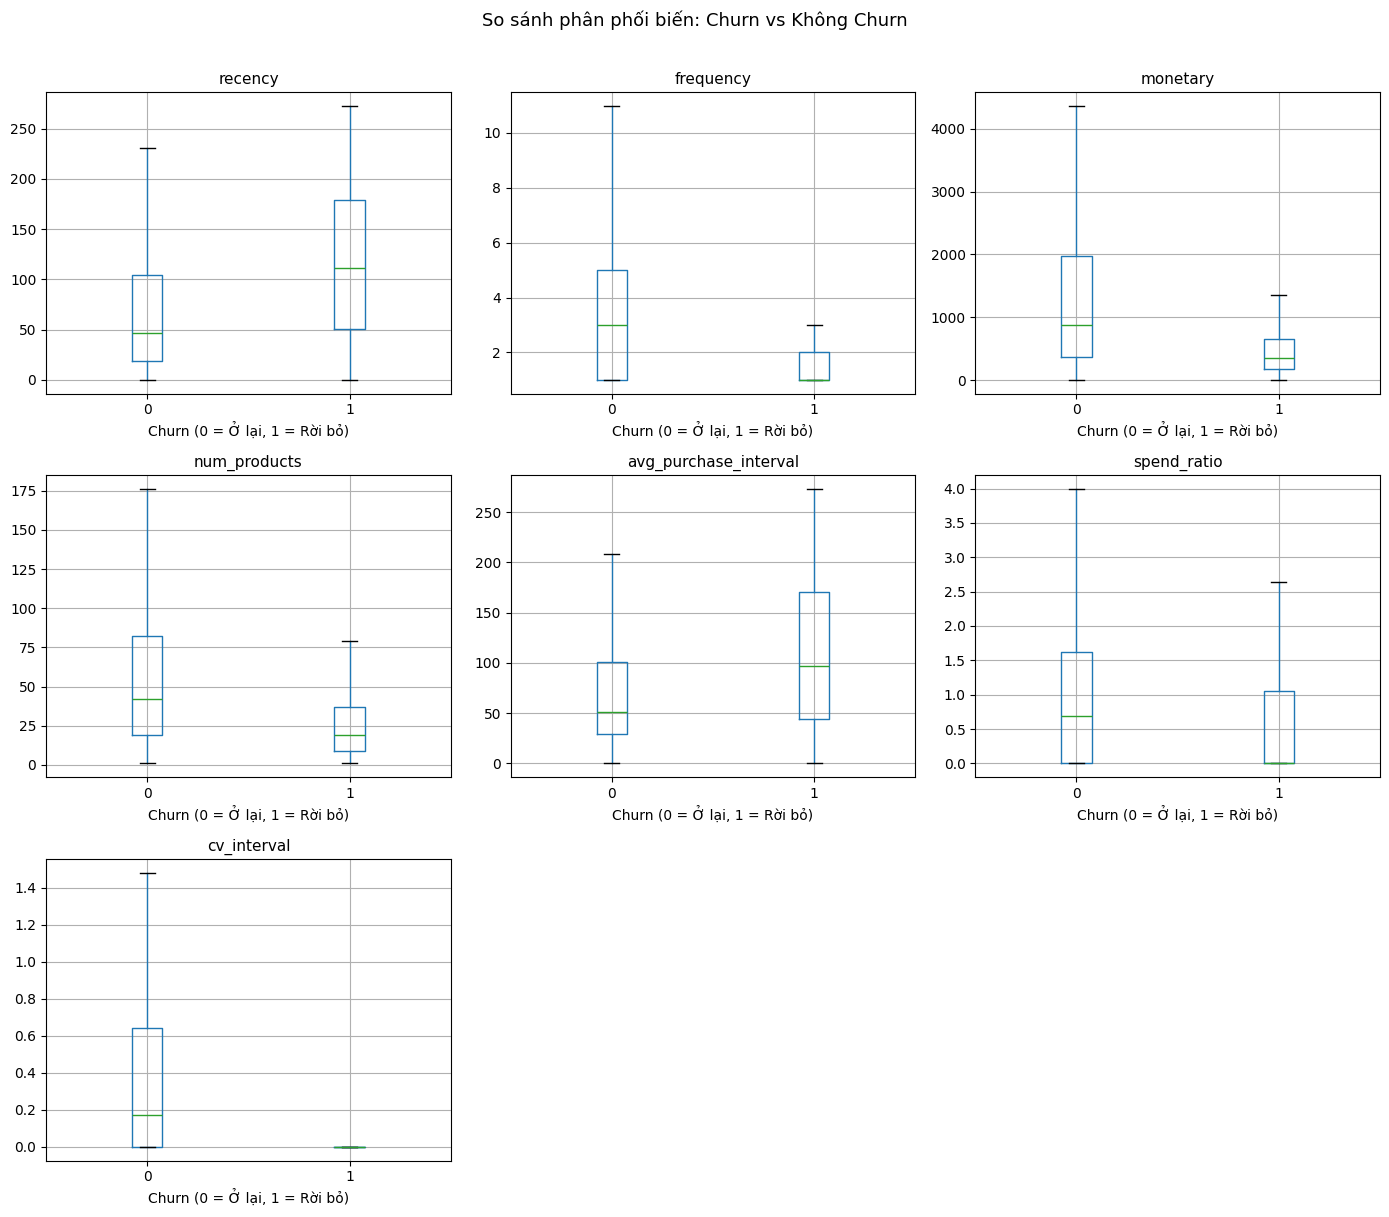

In [15]:
# ============================================================
# VISUALIZE: Boxplot so sánh phân phối giữa 2 nhóm
# ============================================================

n_cols = 3
n_rows = (len(selected_continuous) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(selected_continuous):
    data.boxplot(column=col, by='churn', ax=axes[i], showfliers=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Churn (0 = Ở lại, 1 = Rời bỏ)')

# Ẩn các ô thừa
for j in range(len(selected_continuous), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('So sánh phân phối biến: Churn vs Không Churn', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 🤖 Bước 5: Huấn luyện mô hình

In [16]:
# ============================================================
# CHUẨN BỊ DỮ LIỆU
# ============================================================

X = data[selected_features].copy()
y = data['churn'].copy()

# Chia 80% train / 20% test — stratify giữ nguyên tỷ lệ churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tập huấn luyện : {X_train.shape[0]:,} khách hàng')
print(f'Tập kiểm tra   : {X_test.shape[0]:,} khách hàng')
print(f'Tỷ lệ churn train: {y_train.mean():.1%}')
print(f'Tỷ lệ churn test : {y_test.mean():.1%}')

# Chuẩn hóa (cần thiết cho Logistic Regression)
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)   # Chỉ transform, KHÔNG fit lại

print('\n✅ Chuẩn bị dữ liệu xong!')


Tập huấn luyện : 2,653 khách hàng
Tập kiểm tra   : 664 khách hàng
Tỷ lệ churn train: 43.6%
Tỷ lệ churn test : 43.5%

✅ Chuẩn bị dữ liệu xong!


In [17]:
# ============================================================
# MÔ HÌNH 1: LOGISTIC REGRESSION
# ============================================================

print('--- Huấn luyện Logistic Regression ---')

lr_model = LogisticRegression(
    class_weight='balanced',  # Tự bù đắp khi dữ liệu mất cân bằng
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('\n📊 Kết quả Logistic Regression:')
print(classification_report(y_test, y_pred_lr, target_names=['Ở lại', 'Rời bỏ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')


--- Huấn luyện Logistic Regression ---

📊 Kết quả Logistic Regression:
              precision    recall  f1-score   support

       Ở lại       0.77      0.60      0.67       375
      Rời bỏ       0.60      0.77      0.67       289

    accuracy                           0.67       664
   macro avg       0.68      0.68      0.67       664
weighted avg       0.69      0.67      0.67       664

ROC-AUC: 0.7385


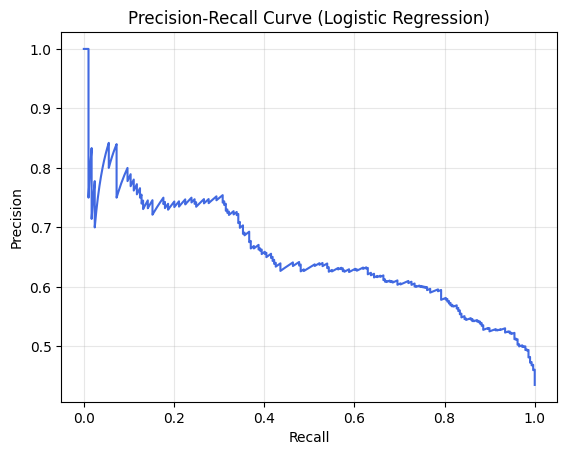

In [18]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)

plt.plot(recall, precision, color='royalblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Logistic Regression)')
plt.grid(alpha=0.3)
plt.show()


In [19]:
# ============================================================
# MÔ HÌNH 2: XGBOOST (đã tinh chỉnh để vượt Logistic Regression)
# ============================================================

print('--- Huấn luyện XGBoost ---')

# Tính tỷ lệ để bù đắp mất cân bằng nhãn
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators         = 300,   # Nhiều cây hơn, kết hợp với learning_rate thấp
    max_depth            = 3,     # Cây nông → giảm overfit trên dataset vừa
    learning_rate        = 0.05,  # Học chậm → tổng quát hóa tốt hơn
    subsample            = 0.8,   # Mỗi cây chỉ dùng 80% dữ liệu → giảm overfit
    colsample_bytree     = 0.8,   # Mỗi cây chỉ dùng 80% biến → tăng đa dạng
    min_child_weight     = 5,     # Node lá cần ≥ 5 mẫu → tránh học nhiễu
    reg_alpha            = 0.1,   # L1 regularization → tự loại biến yếu
    reg_lambda           = 1.5,   # L2 regularization → phạt trọng số lớn
    scale_pos_weight     = scale_pos_weight,
    eval_metric          = 'logloss',
    early_stopping_rounds= 20,    # Tự dừng khi không cải thiện sau 20 vòng
    random_state         = 42
)

# XGBoost không cần chuẩn hóa — dùng X_train / X_test gốc
# eval_set giúp theo dõi hiệu suất trên test để early stopping hoạt động
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50   # In kết quả mỗi 50 vòng — theo dõi loss có giảm không
)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('\n📊 Kết quả XGBoost:')
print(classification_report(y_test, y_pred_xgb, target_names=['Ở lại', 'Rời bỏ']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')


--- Huấn luyện XGBoost ---
scale_pos_weight = 1.29
[0]	validation_0-logloss:0.68459
[50]	validation_0-logloss:0.58965
[70]	validation_0-logloss:0.59092

📊 Kết quả XGBoost:
              precision    recall  f1-score   support

       Ở lại       0.77      0.59      0.67       375
      Rời bỏ       0.59      0.77      0.67       289

    accuracy                           0.67       664
   macro avg       0.68      0.68      0.67       664
weighted avg       0.69      0.67      0.67       664

ROC-AUC: 0.7418


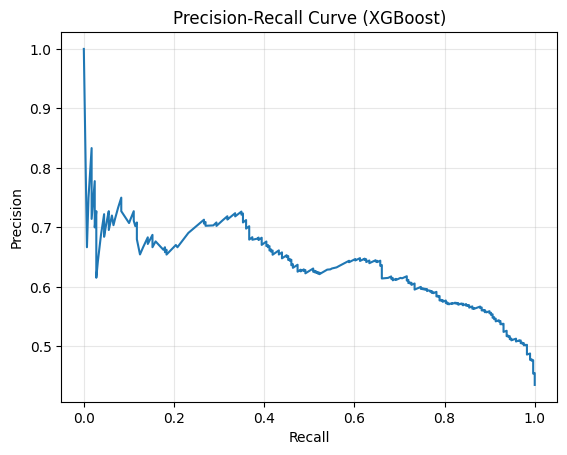

In [20]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (XGBoost)')
plt.grid(alpha=0.3)
plt.show()



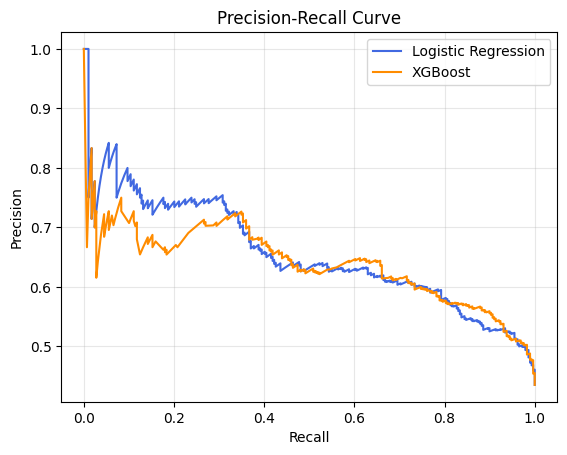

In [21]:
# so sánh biểu đồ giữa 2 mô hình 
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, y_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(rec_lr,  prec_lr,  label='Logistic Regression', color='royalblue')
plt.plot(rec_xgb, prec_xgb, label='XGBoost',             color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## 📈 Bước 6: Đánh giá và so sánh mô hình

In [22]:
# ============================================================
# SO SÁNH HAI MÔ HÌNH
# ============================================================

comparison = pd.DataFrame({
    'Mô hình' : ['Logistic Regression', 'XGBoost'],
    'ROC-AUC' : [
        round(roc_auc_score(y_test, y_prob_lr),  4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ]
})

print('=== BẢNG SO SÁNH MÔ HÌNH ===')
display(comparison)

best_idx   = comparison['ROC-AUC'].idxmax()
best_model = comparison.loc[best_idx, 'Mô hình']
print(f'\n🏆 Mô hình tốt hơn: {best_model}')


=== BẢNG SO SÁNH MÔ HÌNH ===


,Mô hình,ROC-AUC
0,Logistic Regression,0.7385
1,XGBoost,0.7418



🏆 Mô hình tốt hơn: XGBoost


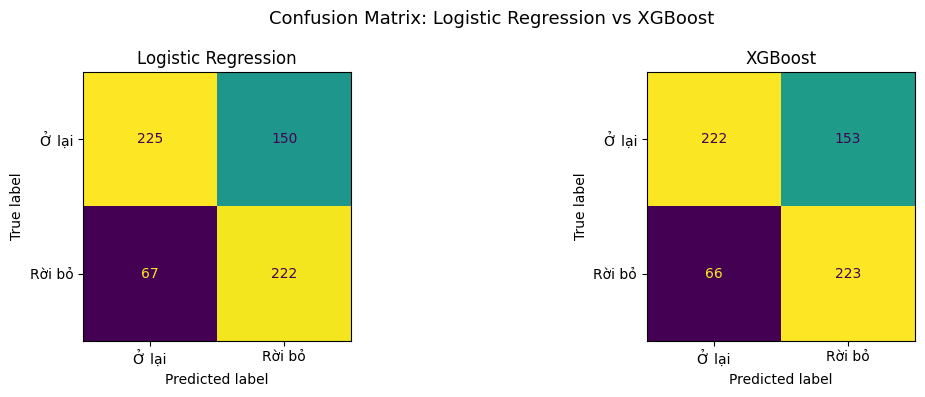


📖 Cách đọc Confusion Matrix:
  True Positive  (TP): Dự đoán đúng khách rời bỏ        → TỐT
  True Negative  (TN): Dự đoán đúng khách ở lại          → TỐT
  False Positive (FP): Nghĩ rời bỏ nhưng thực ra ở lại  → Lãng phí chi phí marketing
  False Negative (FN): Nghĩ ở lại nhưng thực ra rời bỏ  → Bỏ sót khách cần giữ



In [23]:
# ============================================================
# CONFUSION MATRIX cho cả 2 mô hình
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Ở lại', 'Rời bỏ'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Ở lại', 'Rời bỏ'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('XGBoost')

plt.suptitle('Confusion Matrix: Logistic Regression vs XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

print("""
📖 Cách đọc Confusion Matrix:
  True Positive  (TP): Dự đoán đúng khách rời bỏ        → TỐT
  True Negative  (TN): Dự đoán đúng khách ở lại          → TỐT
  False Positive (FP): Nghĩ rời bỏ nhưng thực ra ở lại  → Lãng phí chi phí marketing
  False Negative (FN): Nghĩ ở lại nhưng thực ra rời bỏ  → Bỏ sót khách cần giữ
""")


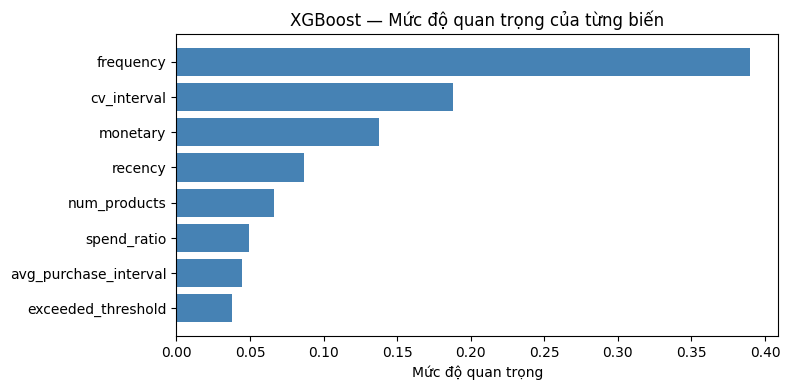

Bảng chi tiết:
                 Biến  Importance
            frequency    0.389462
          cv_interval    0.188238
             monetary    0.137452
              recency    0.086463
         num_products    0.066351
          spend_ratio    0.049665
avg_purchase_interval    0.044357
   exceeded_threshold    0.038013


In [24]:
# ============================================================
# FEATURE IMPORTANCE — XGBoost
# ============================================================

importance_df = pd.DataFrame({
    'Biến'      : selected_features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, max(4, len(selected_features) * 0.5)))
plt.barh(importance_df['Biến'], importance_df['Importance'], color='steelblue')
plt.xlabel('Mức độ quan trọng')
plt.title('XGBoost — Mức độ quan trọng của từng biến')
plt.tight_layout()
plt.show()

print('Bảng chi tiết:')
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))


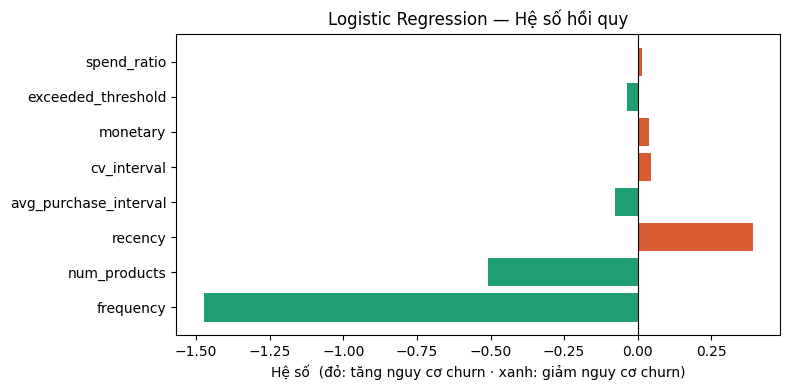

Bảng chi tiết:
                 Biến     Hệ số
            frequency -1.473904
         num_products -0.508002
              recency  0.390008
avg_purchase_interval -0.078573
          cv_interval  0.044323
             monetary  0.038582
   exceeded_threshold -0.034763
          spend_ratio  0.013226


In [25]:
# ============================================================
# HỆ SỐ HỒI QUY — Logistic Regression
# ============================================================

coef_df = pd.DataFrame({
    'Biến'  : selected_features,
    'Hệ số' : lr_model.coef_[0]
}).sort_values('Hệ số', key=abs, ascending=False)

colors = ['#D85A30' if c > 0 else '#1D9E75' for c in coef_df['Hệ số']]

plt.figure(figsize=(8, max(4, len(selected_features) * 0.5)))
plt.barh(coef_df['Biến'], coef_df['Hệ số'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Hệ số  (đỏ: tăng nguy cơ churn · xanh: giảm nguy cơ churn)')
plt.title('Logistic Regression — Hệ số hồi quy')
plt.tight_layout()
plt.show()

print('Bảng chi tiết:')
print(coef_df.to_string(index=False))


---
## 🎯 Bước 7: Xếp hạng khách hàng theo nguy cơ churn

In [26]:
# ============================================================
# XẾP HẠNG KHÁCH HÀNG THEO XÁC SUẤT CHURN
# Dùng mô hình có ROC-AUC cao hơn
# ============================================================

y_prob_best = y_prob_xgb if best_model == 'XGBoost' else y_prob_lr

result_df = X_test.copy()
result_df['customerid'] = data.loc[X_test.index, 'customerid'].values
result_df['churn_thuc'] = y_test.values
result_df['churn_prob'] = y_prob_best

# Phân loại mức độ nguy cơ
result_df['risk_level'] = pd.cut(
    result_df['churn_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Thấp', 'Trung bình', 'Cao']
)

# Top 20 khách hàng nguy cơ cao nhất
top_churn = (
    result_df
    .sort_values('churn_prob', ascending=False)
    .head(20)
    [['customerid', 'recency', 'frequency', 'monetary', 'churn_prob', 'risk_level']]
    .reset_index(drop=True)
)

print(f'=== TOP 20 KHÁCH HÀNG NGUY CƠ CAO NHẤT ({best_model}) ===')
display(top_churn)


=== TOP 20 KHÁCH HÀNG NGUY CƠ CAO NHẤT (XGBoost) ===


,customerid,recency,frequency,monetary,churn_prob,risk_level
0,16078,183,1,79.20,0.783767,Cao
1,18068,189,1,101.70,0.783767,Cao
2,14473,182,1,85.00,0.783767,Cao
3,13747,273,1,79.60,0.779684,Cao
4,17763,163,1,15.00,0.771323,Cao
5,17102,161,1,25.50,0.771323,Cao
6,14608,262,1,204.00,0.765844,Cao
7,15070,272,1,106.20,0.765810,Cao
8,15562,251,1,134.55,0.765810,Cao
9,18080,142,1,841.50,0.745295,Cao


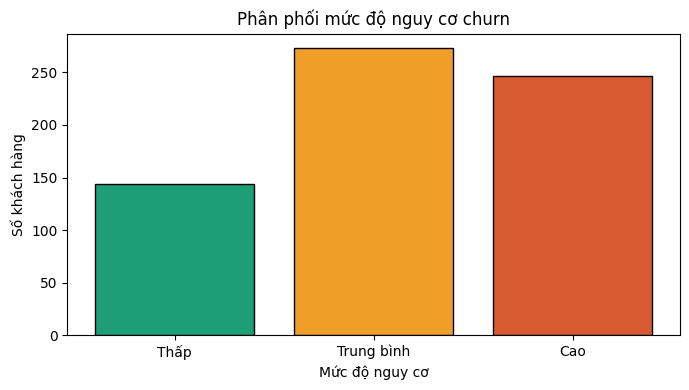

Số khách hàng theo từng nhóm nguy cơ:
risk_level
Thấp          144
Trung bình    273
Cao           247


In [27]:
# ============================================================
# PHÂN PHỐI MỨC ĐỘ NGUY CƠ
# ============================================================

risk_counts = result_df['risk_level'].value_counts().reindex(['Thấp', 'Trung bình', 'Cao'])

plt.figure(figsize=(7, 4))
plt.bar(risk_counts.index, risk_counts.values,
        color=['#1D9E75', '#EF9F27', '#D85A30'], edgecolor='black')
plt.title('Phân phối mức độ nguy cơ churn')
plt.xlabel('Mức độ nguy cơ')
plt.ylabel('Số khách hàng')
plt.tight_layout()
plt.show()

print('Số khách hàng theo từng nhóm nguy cơ:')
print(risk_counts.to_string())


---
## 📝 Tổng kết

### Những gì đã thực hiện:

1. **Làm sạch dữ liệu** — loại bỏ giao dịch lỗi, hủy, thiếu CustomerID
2. **Phân tích chu kỳ mua** — kiểm chứng thống kê cho ngưỡng 90 ngày
3. **Tạo 9 features** — RFM cơ bản + 3 biến cải tiến (spend_ratio, cv_interval, exceeded_threshold)
4. **Kiểm định T-Test & Chi-Square** — chỉ giữ biến có p-value < 0.05
5. **Huấn luyện 2 mô hình** — Logistic Regression và XGBoost (đã tinh chỉnh regularization)
6. **Đánh giá** — ROC-AUC, Confusion Matrix, Feature Importance
7. **Xếp hạng khách hàng** theo xác suất churn

### Hành động đề xuất:

| Nguy cơ | Ngưỡng | Hành động |
|---------|--------|-----------|
| Cao | > 60% | Gọi điện cá nhân, voucher giảm giá mạnh |
| Trung bình | 30–60% | Email nhắc nhở, đề xuất sản phẩm liên quan |
| Thấp | < 30% | Duy trì chương trình loyalty bình thường |